# F01 · What the AI does and what you must understand

<!-- paper-first -->
### Research question

**Reading:** [PD01](../../curriculum/papers/design.md#pd01). Review the assigned figure or result before starting the lesson.

**Question:** Which decisions in the NARPS analysis path would remain your responsibility if AI wrote every line?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

<!-- key-references -->
### Why this technique matters

Every neuroimaging preprocessing and modeling step transforms array shapes, physical units, and statistical conditioning sets. Without an explicit transformation contract, a syntactically valid snippet can demean across space instead of time (passing a naive global-mean check while injecting global-signal artifacts) or alter group-level GLM effect sizes (beta_hat) across coil sensitivity profiles even though single-voxel t-statistics remain invariant.

**Key references** · *Input-to-output transformation contracts, axis semantics, and temporal scaling invariants (demeaning, percent signal change, z-scoring)*

- *Foundational* — Nichols et al. (2017), [Best practices in data analysis and sharing in neuroimaging using MRI](https://doi.org/10.1038/nn.4500), *Nature Neuroscience*. Establishes the COBIDAS standards for explicitly reporting analytical contracts, parameterization, scaling, and software provenance in MRI workflows.
- *Critical evaluation* — Botvinik-Nezer et al. (2020), [Variability in the analysis of a single neuroimaging dataset by many teams](https://doi.org/10.1038/s41586-020-2314-9), *Nature*. Demonstrates across 70 teams that unstandardized analytical and scaling contracts yield substantial divergence in binary fMRI hypothesis decisions on identical data. Course library: [PD01](../../curriculum/papers/design.md#pd01).
- *Review* — Poldrack et al. (2020), [Establishment of Best Practices for Evidence for Prediction: A Review](https://doi.org/10.1001/jamapsychiatry.2019.3671), *JAMA Psychiatry*. Defines rigorous input-output validation contracts, train/test separation rules, and metric selection standards for predictive neuroimaging models.

Full entries, verification status and citation counts: [course bibliography](../../curriculum/papers/REFERENCES.md#f01).
<!-- /key-references -->

**Learning format:** predict $\to$ ask AI for one short operation $\to$ run $\to$ inspect $\to$ deliberately break $\to$ explain. Use Goose with a local Ollama model, or ChatGPT as a tutor and snippet writer. You are responsible for deciding whether the transformation answers the research question. Read the answer guide only after making your own prediction.

**Time:** 60–90 minutes. **Prerequisite:** R00–R03 orientation seminars.

---

### 1. Scientific Supervision vs. Unsupervised Code Generation

This course trains you in the **scientific supervision of computational neuroimaging workflows**. You do not need to memorize obscure library flags, but you must be able to state what every array dimension, physical unit, participant index, coordinate frame, and statistical comparison means. When 70 expert teams analyzed the exact same $N = 108$ mixed-gambles fMRI dataset in the Neuroimaging Analysis Replication and Prediction Study ([NARPS, Botvinik-Nezer et al., 2020, `PD01`](../../curriculum/papers/design.md#pd01)), binary hypothesis decisions varied widely even though every team ran valid, crash-free software (motivating community reporting and validation standards such as COBIDAS, Nichols et al., 2017, and predictive modeling best practices, Poldrack et al., 2020). In modern AI-assisted research, an LLM can generate a syntactically flawless 20-line Python snippet in two seconds that silently changes your scientific question—for example, by standardizing across space instead of time, rescaling baseline differences across patients, or leaking test-set statistics into training folds.

The central supervisory skill is **specifying and auditing the input-to-output transformation contract** before accepting any computational result.

### 2. Formalizing a Transformation Contract

In mathematical analysis and scientific computing, every operation $f: \mathcal{X} \to \mathcal{Y}$ is governed by a six-part **Transformation Contract**:

1. **Input Domain, Shape, & Axis Semantics ($\mathcal{X}$):** What is the tensor shape, data type (`float32`, `float64`, integer mask), and physical meaning of each axis? In neuroimaging, a 2D matrix $\mathbf{X}$ might be organized as $(\text{Voxels } V, \text{Time } T)$ in Nilearn/FSL helpers or $(\text{Time } T, \text{Voxels } V)$ in `scikit-learn` estimators, while a 4D NIfTI volume has shape $(X, Y, Z, T)$. An operation without explicit axis semantics is scientifically ambiguous.
2. **Physical & Statistical Units:** What do the numbers measure? Raw MRI intensities are arbitrary scanner analog-to-digital converter (ADC) units; centered signals retain raw ADC units; Percent Signal Change (PSC) has units of $\%$ relative to local temporal baseline; $z$-scores are dimensionless standard-deviation units ($\sigma$).
3. **Hyperparameters vs. Fitted Statistics ($\theta_{\text{fixed}}$ vs. $\hat{\theta}_{\text{data}}$):** Which parameters are chosen *a priori* by the researcher (e.g., `ddof=0`, smoothing $\text{FWHM} = 6\text{ mm}$, high-pass cutoff $0.01\text{ Hz}$) and which are **learned from the data** (e.g., voxel baseline mean $\hat{\mu}_v$ and standard deviation $\hat{\sigma}_v$)? Crucially, *over which observations* are $\hat{\theta}_{\text{data}}$ estimated?
4. **Preserved Invariants:** Which mathematical properties must remain unchanged after the transformation? For example, temporal centering preserves all pairwise temporal differences $x_{v,t_2} - x_{v,t_1}$ and temporal variance $\sigma_v^2$, while shifting the temporal mean to exactly $0$.
5. **Lost / Destroyed Information:** Which properties are permanently erased? Temporal centering destroys the static baseline tissue intensity $\mu_v$ (so you can no longer distinguish bright CSF from darker white matter or detect a $T_2^*$ susceptibility dropout cavity from the centered time series alone). Temporal $z$-scoring additionally destroys the absolute fluctuation amplitude $\sigma_v$.
6. **Rejection & Falsification Criteria:** What numerical assertion (`assert`) and visual diagnostic plot would force you to reject the output?

### 3. Linear Algebra of Centering, Percent Signal Change, and $Z$-Scoring

Consider a single voxel's BOLD time series $\mathbf{x}_v = [x_{v,1}, x_{v,2}, \dots, x_{v,T}]^\top \in \mathbb{R}^T$, with sample mean $\bar{x}_v = \frac{1}{T}\mathbf{1}^\top \mathbf{x}_v$ and variance $s_{v,\text{ddof}}^2 = \frac{1}{T - \text{ddof}}\|\mathbf{x}_v - \bar{x}_v \mathbf{1}\|_2^2$. Compare the three standard fMRI scaling contracts:

| Transformation | Mathematical Formula | Output Units | Preserved Invariants | Destroyed Information | Impact on First-Level GLM $\hat{\beta}_v$ vs. $t_v$ |
|---|---|---|---|---|---|
| **Temporal Centering (Demeaning)** | $\tilde{\mathbf{x}}_v = \mathbf{x}_v - \bar{x}_v \mathbf{1} = \left(\mathbf{I}_T - \frac{1}{T}\mathbf{1}\mathbf{1}^\top\right)\mathbf{x}_v$ | Raw scanner units (ADC) | Pairwise differences $\Delta x$, variance $s_v^2$, Pearson correlation $r$ | Static baseline offset $\bar{x}_v$ (DC component) | Preserves slope $\hat{\beta}_v$ on centered regressors and $t_v$ statistic |
| **Percent Signal Change (PSC)** | $\mathbf{p}_v = 100 \cdot \frac{\mathbf{x}_v - \bar{x}_v \mathbf{1}}{\bar{x}_v}$ (requires $\bar{x}_v > \tau$) | $\%$ of voxel baseline $\bar{x}_v$ | Relative amplitude ratios, Pearson correlation $r$, single-voxel $t_v$ | Raw baseline $\bar{x}_v$; fails near zero / air / dropout | Rescales $\hat{\beta}_v$ by $\frac{100}{\bar{x}_v}$ (standard in downstream fMRI GLM workflows such as `P02`), while $t_v$ is invariant |
| **Temporal $Z$-Scoring** | $\mathbf{z}_v = \frac{\mathbf{x}_v - \bar{x}_v \mathbf{1}}{s_{v,\text{ddof}}}$ | Dimensionless ($\sigma$ units) | Mean $= 0$, SD $= 1$, Pearson correlation $r$, single-voxel $t_v$ | Both baseline $\bar{x}_v$ and amplitude variance $s_v^2$ | Rescales $\hat{\beta}_v$ by $\frac{1}{s_v}$ (converts regression slope into correlation scale) |

> **Why this matters for NARPS (`PD01`) and Foundation Models (`PM05`):** Within a single voxel's ordinary least-squares (OLS) regression against a zero-mean task regressor, multiplying the voxel time series by any positive constant $c_v > 0$ multiplies both the effect estimate $\hat{\beta}_v$ and its standard error $\text{SE}(\hat{\beta}_v)$ by $c_v$—leaving the single-subject $t$-statistic $t_v = \hat{\beta}_v / \text{SE}(\hat{\beta}_v)$ **invariant**. However, when teams carry $\hat{\beta}_v$ contrast maps to a **second-level group analysis** across participants (`PD01`), or when a foundation model like *Omni-fMRI* (`PM05`) computes variance-based dynamic patches across neighboring voxels, whether voxels were scaled by PSC ($c_v = 100/\bar{x}_v$) or $z$-scored ($c_v = 1/s_v$) changes the relative weighting of noisy vs. high-signal voxels across the brain.

### 4. Supervisory Protocol & Data Privacy Boundary

In every computational lesson, use this supervisory prompt with your AI assistant:
> **“Ask me to predict this operation's output shape, units, and invariants before writing code. Then give at most 15 lines for that single transformation. Name all axes and units, state which statistics are fitted and on which observations, include one `assert` numerical check and one visual check, and wait for my scientific interpretation.”**

This course uses controlled synthetic phantoms to expose failure modes and public teaching datasets for integration. Never paste identifiable participant metadata or clinical scans into an unapproved cloud LLM; consult the [AI workflow guide](../../curriculum/AI_WORKFLOW.md) for local Ollama/Goose vs. cloud boundaries.


### Step 1 · Predict and Verify 1D Transformation Contracts

Before running the cell below, write down your prediction:
1. For the 4-point signal `[98., 100., 102., 104.]`, what is the temporal mean $\mu$, what are the adjacent first differences `np.diff`, and why does centering preserve `np.diff` while $z$-scoring changes it?
2. What is the difference between `ddof=0` (maximum-likelihood population standard deviation, dividing by $\sqrt{T}$) and `ddof=1` (sample standard deviation, dividing by $\sqrt{T-1}$), and by what exact factor $\sqrt{T/(T-1)}$ do their $z$-scores differ when $T=4$?


In [1]:
import numpy as np

signal = np.array([98., 100., 102., 104.])
centered = signal - signal.mean()
z = centered / signal.std(ddof=0)
z_sample = centered / signal.std(ddof=1)
psc = 100.0 * centered / signal.mean()

# Contract assertions: mean, difference invariance, and scale normalization
assert np.isclose(centered.mean(), 0)
assert np.allclose(np.diff(centered), np.diff(signal))
assert np.isclose(z.std(ddof=0), 1)
assert np.isclose(z_sample.std(ddof=1), 1)
assert np.allclose(z / z_sample, np.sqrt(len(signal) / (len(signal) - 1)))
assert np.isclose(psc.mean(), 0) and np.allclose(psc, centered * (100.0 / 101.0))

print('raw:', signal, '\ncentered:', centered, '\nz:', z)
print('z (ddof=1):', np.round(z_sample, 6), '\npercent signal change (%):', np.round(psc, 4))


raw: [ 98. 100. 102. 104.] 
centered: [-3. -1.  1.  3.] 
z: [-1.34164079 -0.4472136   0.4472136   1.34164079]
z (ddof=1): [-1.161895 -0.387298  0.387298  1.161895] 
percent signal change (%): [-2.9703 -0.9901  0.9901  2.9703]


### Step 2 · Catch an Attractive Wrong Answer: Temporal vs. Spatial Demeaning

In 2D neuroimaging matrices of shape `(V, T)` (rows = voxels, columns = time points) or 4D volumes `(X, Y, Z, T)`, an AI assistant asked to "demean the fMRI data" will frequently write `data - data.mean(axis=0, keepdims=True)`—or worse, `data - data.mean()`.
- **Contract `right` (`axis=1` in 2D, `axis=-1` in 4D):** Subtracts each voxel's own temporal baseline $\bar{x}_{v,\cdot}$ across time. Every voxel's time series now has mean $0$, and static tissue contrast between gray matter ($\bar{x} \approx 200$) and CSF/white matter ($\bar{x} \approx 100$) is removed.
- **Bug `wrong` (`axis=0` in 2D, `axis=(0,1,2)` in 4D):** Subtracts the **spatial average across all voxels** $\bar{x}_{\cdot,t}$ at each time point $t$ (a crude Global Signal subtraction) *without* removing each voxel's static baseline! Notice that both `right.mean()` and `wrong.mean()` equal `0.0` globally—proving why a naive `assert np.isclose(output.mean(), 0)` fails to catch an axis bug!


In [2]:
data = np.array([[98., 100., 102.], [198., 200., 202.]])  # rows=voxels (V=2), columns=time (T=3)
right = data - data.mean(axis=1, keepdims=True)
wrong = data - data.mean(axis=0, keepdims=True)

assert np.allclose(right.mean(axis=1), 0)
assert not np.allclose(wrong.mean(axis=1), 0)
# Notice the trap: both arrays have a global grand mean of 0.0!
assert np.isclose(right.mean(), 0) and np.isclose(wrong.mean(), 0)
print('right voxel means:', right.mean(axis=1))
print('wrong voxel means:', wrong.mean(axis=1))

# Extend to a 4D synthetic fMRI phantom of shape (X=8, Y=8, Z=4, T=60)
rng = np.random.default_rng(42)
X, Y, Z, T = 8, 8, 4, 60
t_grid = np.linspace(0, 4 * np.pi, T)
task_wave = np.sin(t_grid)  # zero-mean task oscillation

# Spatially heterogeneous T2* baseline (100 in inner core, 220 in outer cortex)
baseline_3d = np.full((X, Y, Z, 1), 220.0)
baseline_3d[2:6, 2:6, 1:3, 0] = 100.0
active_mask = np.zeros((X, Y, Z, 1), dtype=bool)
active_mask[3:5, 3:5, 1:3, 0] = True

phantom_4d = (
    baseline_3d
    + 3.5 * active_mask * task_wave.reshape(1, 1, 1, T)
    + rng.normal(0, 1.5, size=(X, Y, Z, T))
)

# Correct temporal centering along T (axis=-1) vs. wrong spatial centering along (0,1,2)
centered_time_4d = phantom_4d - phantom_4d.mean(axis=-1, keepdims=True)
centered_space_4d = phantom_4d - phantom_4d.mean(axis=(0, 1, 2), keepdims=True)

assert np.allclose(centered_time_4d.mean(axis=-1), 0.0, atol=1e-12)
assert np.max(np.abs(centered_space_4d.mean(axis=-1))) > 50.0
print('4D phantom shape:', phantom_4d.shape, '| Max residual voxel offset (time-centered vs space-centered):',
      round(float(np.max(np.abs(centered_time_4d.mean(axis=-1)))), 6), 'vs',
      round(float(np.max(np.abs(centered_space_4d.mean(axis=-1)))), 2))


right voxel means: [0. 0.]
wrong voxel means: [-50.  50.]
4D phantom shape: (8, 8, 4, 60) | Max residual voxel offset (time-centered vs space-centered): 0.0 vs 105.32


### Step 3 · How Scaling Contracts Impact GLM Effect Sizes ($\hat{\beta}$) vs. $t$-Statistics Across SNR

Why do neuroimaging pipelines care so deeply about whether time series are centered, converted to Percent Signal Change (`PP01`), or $z$-scored? Let us test what happens when two voxels (or two participants in a cohort) have **identical true percent BOLD change ($2.0\%$ of local baseline)** but **different baseline coil intensities ($B_v \in [80, 320]$)** or **different thermal noise levels ($\sigma_v$)**:
- In raw or centered ADC units, a $2\%$ change on a baseline of $300$ produces a regression slope $\hat{\beta} = 6.0$, whereas the exact same $2\%$ physiological response on a baseline of $100$ (e.g., deeper from the head coil) produces $\hat{\beta} = 2.0$!
- In **Percent Signal Change (PSC)**, both voxels correctly recover $\hat{\beta}_{\text{PSC}} \approx 2.0\%$.
- In **$Z$-scoring**, $\hat{\beta}_z$ is divided by the total time-series standard deviation $\sigma_v$, so a voxel with higher thermal noise has its effect size shrunk toward zero!
- Yet within each single voxel's OLS regression, the **single-voxel $t$-statistic** $t_v = \hat{\beta}_v / \text{SE}(\hat{\beta}_v)$ is **strictly invariant** across Centered, PSC, and $Z$-scoring (because both numerator and denominator scale by the same positive factor $c_v$)!


In [3]:
# Simulate V=120 voxels with varying coil baseline intensity B_v and constant 2.0% physiological task effect
V_sim = 120
baselines = np.linspace(80.0, 320.0, V_sim).reshape(V_sim, 1)
noise_sd = np.linspace(1.2, 4.8, V_sim).reshape(V_sim, 1)
true_psc = 2.0  # 2% BOLD change

# Design regressor x (zero mean, unit amplitude)
x_reg = task_wave - task_wave.mean()
Y_raw = baselines * (1.0 + (true_psc / 100.0) * x_reg.reshape(1, T)) + rng.normal(0, 1.0, size=(V_sim, T)) * noise_sd

# Apply three valid temporal contracts + one wrong-axis contract
Y_cent = Y_raw - Y_raw.mean(axis=1, keepdims=True)
Y_psc = 100.0 * Y_cent / Y_raw.mean(axis=1, keepdims=True)
Y_z = Y_cent / Y_raw.std(axis=1, ddof=1, keepdims=True)
Y_wrong_axis = Y_raw - Y_raw.mean(axis=0, keepdims=True)  # Bug: subtracts spatial mean per TR

def ols_fit_1d(Y_mat, x_vec):
    '''Fit OLS slope beta_hat and t-statistic for each row of Y_mat against zero-mean x_vec.'''
    xx = float(np.dot(x_vec, x_vec))
    beta = (Y_mat @ x_vec) / xx
    resid = Y_mat - np.outer(beta, x_vec)
    dof = len(x_vec) - 2
    se = np.sqrt(np.sum(resid ** 2, axis=1) / (dof * xx))
    return beta, beta / se

beta_cent, t_cent = ols_fit_1d(Y_cent, x_reg)
beta_psc, t_psc = ols_fit_1d(Y_psc, x_reg)
beta_z, t_z = ols_fit_1d(Y_z, x_reg)
beta_wrong, t_wrong = ols_fit_1d(Y_wrong_axis, x_reg)

# Verify mathematical invariance of single-voxel t-statistics under positive per-voxel linear scaling
assert np.allclose(t_cent, t_psc, atol=1e-10)
assert np.allclose(t_cent, t_z, atol=1e-10)
assert not np.allclose(t_cent, t_wrong, atol=1e-2)

print(f"Slope CV across coil baselines -> Centered: {beta_cent.std()/beta_cent.mean():.3f} | "
      f"PSC: {beta_psc.std()/beta_psc.mean():.3f} | Z-scored: {beta_z.std()/beta_z.mean():.3f}")
print(f"Max |t_centered - t_psc|: {np.max(np.abs(t_cent - t_psc)):.2e} | "
      f"Max |t_centered - t_wrong_axis|: {np.max(np.abs(t_cent - t_wrong)):.3f}")


Slope CV across coil baselines -> Centered: 0.370 | PSC: 0.141 | Z-scored: 0.081
Max |t_centered - t_psc|: 3.55e-15 | Max |t_centered - t_wrong_axis|: 10.226


### Step 4 · Visual Diagnostic Dashboard: Auditing Contracts in Space and Time

Numbers and `assert` statements verify specific algebraic properties, but a visual diagnostic dashboard reveals structural patterns across space, time, and parameter regimes. Let us plot a 2x2 supervisory dashboard comparing our transformation contracts.


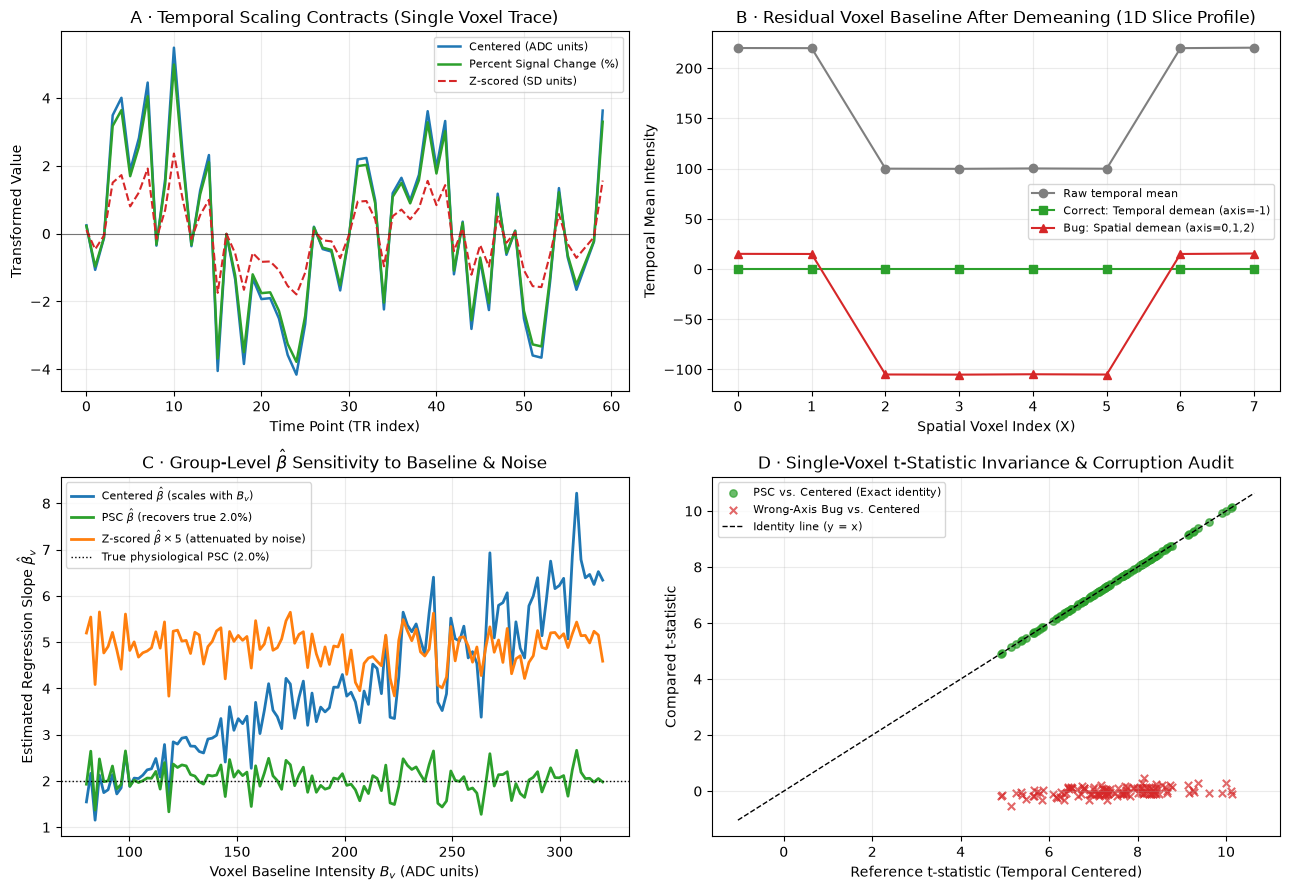

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A: Single-voxel time series under Raw, Centered, PSC, and Z-score contracts
ax = axes[0, 0]
v_idx = 15
ax.plot(Y_cent[v_idx], label='Centered (ADC units)', color='#1f77b4', lw=1.8)
ax.plot(Y_psc[v_idx], label='Percent Signal Change (%)', color='#2ca02c', lw=1.8)
ax.plot(Y_z[v_idx], label='Z-scored (SD units)', color='#d62728', lw=1.5, ls='--')
ax.axhline(0, color='black', lw=0.8, alpha=0.5)
ax.set_title('A · Temporal Scaling Contracts (Single Voxel Trace)')
ax.set_xlabel('Time Point (TR index)')
ax.set_ylabel('Transformed Value')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.25)

# Panel B: Spatial slice of temporal means (Correct axis=-1 vs Wrong spatial axis=(0,1,2))
ax = axes[0, 1]
slice_profile_raw = phantom_4d[:, 4, 2, :].mean(axis=-1)
slice_profile_right = centered_time_4d[:, 4, 2, :].mean(axis=-1)
slice_profile_wrong = centered_space_4d[:, 4, 2, :].mean(axis=-1)
voxels_x = np.arange(X)
ax.plot(voxels_x, slice_profile_raw, 'o-', label='Raw temporal mean', color='#7f7f7f')
ax.plot(voxels_x, slice_profile_right, 's-', label='Correct: Temporal demean (axis=-1)', color='#2ca02c')
ax.plot(voxels_x, slice_profile_wrong, '^-', label='Bug: Spatial demean (axis=0,1,2)', color='#d62728')
ax.set_title('B · Residual Voxel Baseline After Demeaning (1D Slice Profile)')
ax.set_xlabel('Spatial Voxel Index (X)')
ax.set_ylabel('Temporal Mean Intensity')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# Panel C: Effect estimate beta_hat vs. Scanner Coil Baseline B_v
ax = axes[1, 0]
ax.plot(baselines.ravel(), beta_cent, label=r'Centered $\hat{\beta}$ (scales with $B_v$)', color='#1f77b4', lw=2)
ax.plot(baselines.ravel(), beta_psc, label=r'PSC $\hat{\beta}$ (recovers true 2.0%)', color='#2ca02c', lw=2)
ax.plot(baselines.ravel(), beta_z * 5.0, label=r'Z-scored $\hat{\beta} \times 5$ (attenuated by noise)', color='#ff7f0e', lw=2)
ax.axhline(true_psc, color='black', ls=':', lw=1, label='True physiological PSC (2.0%)')
ax.set_title(r'C · Group-Level $\hat{\beta}$ Sensitivity to Baseline & Noise')
ax.set_xlabel('Voxel Baseline Intensity $B_v$ (ADC units)')
ax.set_ylabel(r'Estimated Regression Slope $\hat{\beta}_v$')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# Panel D: Single-voxel t-statistic invariance vs. wrong-axis distortion
ax = axes[1, 1]
ax.scatter(t_cent, t_psc, alpha=0.7, s=28, color='#2ca02c', label='PSC vs. Centered (Exact identity)')
ax.scatter(t_cent, t_wrong, alpha=0.7, s=28, color='#d62728', marker='x', label='Wrong-Axis Bug vs. Centered')
lims = [min(t_cent.min(), t_wrong.min()) - 0.5, max(t_cent.max(), t_wrong.max()) + 0.5]
ax.plot(lims, lims, 'k--', lw=1, label='Identity line (y = x)')
ax.set_title('D · Single-Voxel t-Statistic Invariance & Corruption Audit')
ax.set_xlabel('Reference t-statistic (Temporal Centered)')
ax.set_ylabel('Compared t-statistic')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Explain without AI

1. **Global vs. Per-Voxel Invariants:** Explain mathematically why both `right` (`axis=1`) and `wrong` (`axis=0`) in Step 2 have a grand mean of `0.0` (`array.mean() == 0`), yet only `right` satisfies the per-voxel temporal centering contract. What biological distortion does `wrong` introduce into each voxel's time course?
2. **Effect Size ($\hat{\beta}$) vs. $t$-Statistic Invariance:** Using your Step 3–4 diagnostics, explain why a researcher testing a single-subject $t$-map sees identical $t$-values under Temporal Centering, Percent Signal Change, and $Z$-scoring, whereas a researcher pooling $\hat{\beta}$ contrast maps across subjects (`PD01`) gets different group results depending on the scaling contract.
3. **Draft a Spatial Smoothing Contract:** Write a six-part transformation contract (Input shape/units, Output shape/units, Hyperparameters, Fitted parameters, Preserved invariants, Destroyed information) for 3D Gaussian spatial smoothing ($\text{FWHM} = 6\text{ mm}$), marking any physical-unit conversion you will verify in `P01`.

<details><summary>Answer guide</summary>

1. **Grand Mean Trap:** Subtracting the row mean ($\bar{x}_{v,\cdot}$) makes every row sum to zero; subtracting the column mean ($\bar{x}_{\cdot,t}$) makes every column sum to zero. By Fubini's theorem (associativity of finite sums), the sum of all elements $\sum_v \sum_t \tilde{x}_{v,t}$ is zero in both cases! However, subtracting the spatial column mean $\bar{x}_{\cdot,t}$ leaves each voxel's static tissue offset $\bar{x}_{v,\cdot} - \bar{x}_{\cdot,\cdot}$ intact and injects the negative average of all other brain tissues (Global Signal subtraction) into every voxel.
2. **Invariance vs. Group Pooling:** Multiplying a single voxel's response vector $\mathbf{y}_v$ by $c_v > 0$ scales $\hat{\beta}_v \to c_v \hat{\beta}_v$ and residuals $\mathbf{e}_v \to c_v \mathbf{e}_v$, so $c_v$ cancels in $t_v = \hat{\beta}_v / \text{SE}(\hat{\beta}_v)$. Across voxels or across participants, however, $c_v$ is not constant: PSC weights voxels inversely by baseline intensity ($100/\bar{x}_v$, compensating for RF receive-coil drop-off), whereas $Z$-scoring weights voxels inversely by temporal standard deviation ($1/s_v$, penalizing noisy voxels).
3. **Smoothing Contract Preview:** Input: 3D/4D image array with physical voxel zooms $(\Delta x, \Delta y, \Delta z)$ in mm from the affine header. Hyperparameter: physical kernel $\text{FWHM}$ in mm, converted to voxel standard deviations $\sigma_k = \frac{\text{FWHM}}{\Delta_k \sqrt{8 \ln 2}}$. Preserved: array shape, affine matrix, and global mean intensity (for normalized kernel). Destroyed: high-frequency spatial edges and fine anatomical boundaries (`P01`).

</details>

**Submission:** Record the input, operation, parameters, output, one preserved property, one lost property, and the evidence that would make you reject the result. Include the prompt and any corrections you made to the generated code. A saved answer is not evidence of understanding until you can defend it orally.


### Return to the research question

Revisit [PD01](../../curriculum/papers/design.md#pd01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
